# **Step 1 — Import Libraries**

In [ ]:
import os
import zipfile
import random
import shutil
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm import tqdm
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.20.0


# **Step 2 — Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Step 3 — Extract Dataset**

In [ ]:
ZIP_PATH = "/content/drive/MyDrive/archive.zip"

EXTRACT_PATH = "/content/skin_dataset"

if not os.path.exists(EXTRACT_PATH):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


# **Step 4 — Explore Dataset**

In [ ]:
for root, dirs, files in os.walk(EXTRACT_PATH):
    print(root, len(files))

/content/skin_dataset 0
/content/skin_dataset/test 0
/content/skin_dataset/test/Benign 1000
/content/skin_dataset/test/Malignant 1000
/content/skin_dataset/train 0
/content/skin_dataset/train/Benign 6289
/content/skin_dataset/train/Malignant 5590


# **Step 5 — Locate Train/Test Directories**

In [ ]:
TRAIN_DIR = os.path.join(EXTRACT_PATH, "train")
TEST_DIR = os.path.join(EXTRACT_PATH, "test")

print(TRAIN_DIR)
print(TEST_DIR)

/content/skin_dataset/train
/content/skin_dataset/test


# **Step 6 — Count Images**

In [ ]:
classes = sorted(os.listdir(TRAIN_DIR))

print(classes)
image_count = {}

for c in classes:
    path = os.path.join(TRAIN_DIR, c)
    image_count[c] = len(os.listdir(path))

image_count

['Benign', 'Malignant']


{'Benign': 6289, 'Malignant': 5590}

# **Step 7 — Class Distribution**

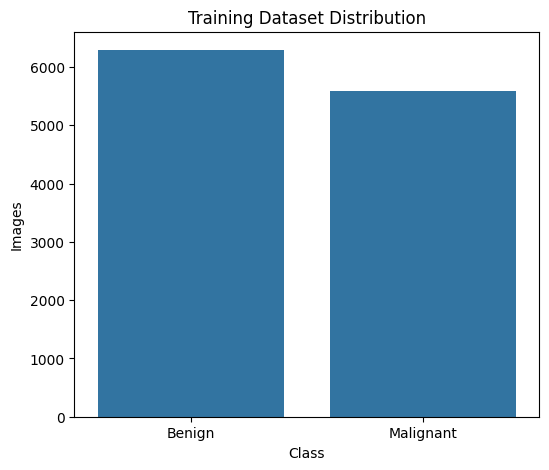

,Class,Images,Percentage
0,Benign,6289,52.94
1,Malignant,5590,47.06


In [ ]:
df = pd.DataFrame(
    image_count.items(),
    columns=["Class","Images"]
)

plt.figure(figsize=(6,5))

sns.barplot(
    x=df["Class"],
    y=df["Images"]
)

plt.title("Training Dataset Distribution")
plt.show()
total = df["Images"].sum()

df["Percentage"] = round(
    df["Images"]/total*100,
    2
)

df

# **Step 8 — Dataset Balance Analysis**

In [ ]:
major = df["Images"].max()
minor = df["Images"].min()

ratio = major/minor

print("Imbalance Ratio :", ratio)

Imbalance Ratio : 1.1250447227191414


# **Step 9 — Show Sample Images**

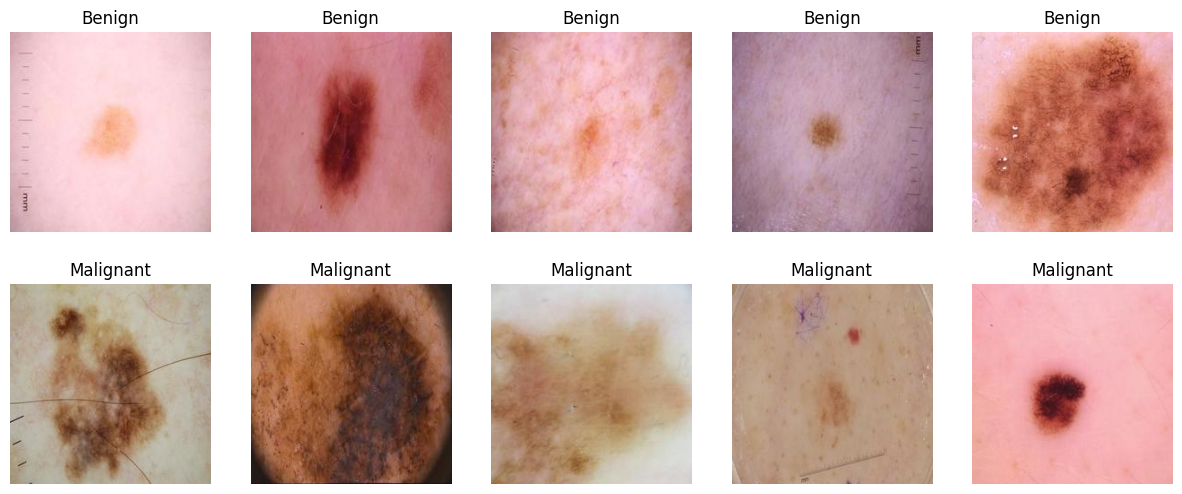

In [ ]:
fig, ax = plt.subplots(2,5, figsize=(15,6))

for row, cls in enumerate(classes):

    folder = os.path.join(TRAIN_DIR, cls)

    images = random.sample(os.listdir(folder),5)

    for col,img in enumerate(images):

        path = os.path.join(folder,img)

        image = Image.open(path)

        ax[row,col].imshow(image)

        ax[row,col].set_title(cls)

        ax[row,col].axis("off")

plt.show()

# **Step 10 — Image Size Analysis**

In [ ]:
sizes=[]

for cls in classes:

    folder=os.path.join(TRAIN_DIR,cls)

    for img in tqdm(os.listdir(folder)):

        path=os.path.join(folder,img)

        image=Image.open(path)

        sizes.append(image.size)


100%|██████████| 5590/5590 [00:00<00:00, 10046.93it/s]


In [ ]:
sizes=pd.DataFrame(
    sizes,
    columns=["Width","Height"]
)

sizes.describe()


,Width,Height
count,11879.0,11879.0
mean,224.0,224.0
std,0.0,0.0
min,224.0,224.0
25%,224.0,224.0
50%,224.0,224.0
75%,224.0,224.0
max,224.0,224.0


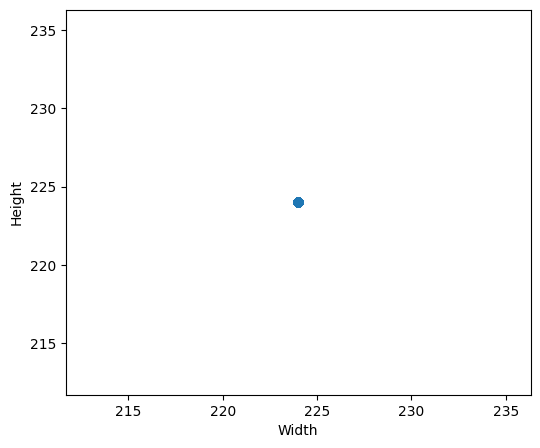

In [ ]:
plt.figure(figsize=(6,5))

plt.scatter(
    sizes["Width"],
    sizes["Height"],
    alpha=0.3
)

plt.xlabel("Width")
plt.ylabel("Height")

plt.show()

# **Step 11 — Check Corrupted Images**

In [ ]:
corrupted=[]

for cls in classes:

    folder=os.path.join(TRAIN_DIR,cls)

    for img in tqdm(os.listdir(folder)):

        path=os.path.join(folder,img)

        try:

            Image.open(path).verify()

        except:

            corrupted.append(path)

print("Corrupted Images :",len(corrupted))

100%|██████████| 5590/5590 [00:00<00:00, 17671.95it/s]

Corrupted Images : 0


# **Step 12 — Compute RGB Mean & Standard Deviation**

In [ ]:
means=[]
stds=[]

for cls in classes:

    folder=os.path.join(TRAIN_DIR,cls)

    imgs=random.sample(os.listdir(folder), min(500, len(os.listdir(folder))))

    for img in tqdm(imgs):

        image=cv2.imread(os.path.join(folder,img))

        image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

        image=image/255.

        means.append(image.mean(axis=(0,1)))

        stds.append(image.std(axis=(0,1)))

mean=np.mean(means,axis=0)
std=np.mean(stds,axis=0)

print("Mean :",mean)
print("Std :",std)

100%|██████████| 500/500 [00:01<00:00, 262.77it/s]

Mean : [0.71598651 0.55409654 0.54245003]
Std : [0.12659648 0.13725434 0.14814391]


# **Step 13 — Brightness Distribution**

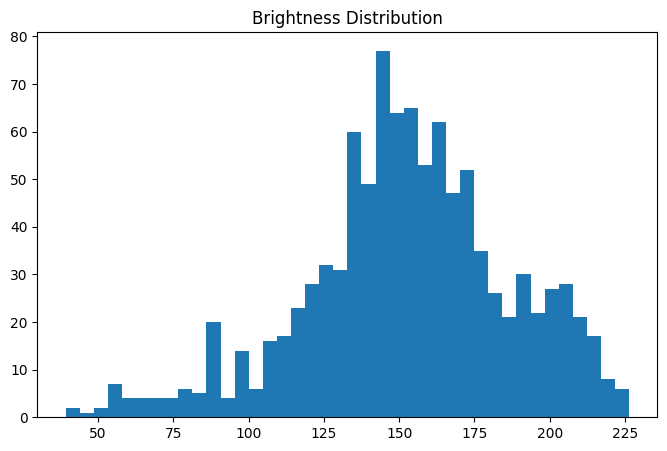

In [ ]:
brightness=[]

for cls in classes:

    folder=os.path.join(TRAIN_DIR,cls)

    imgs=random.sample(os.listdir(folder), min(500, len(os.listdir(folder))))

    for img in imgs:

        image=cv2.imread(os.path.join(folder,img),0)

        brightness.append(image.mean())
plt.figure(figsize=(8,5))

plt.hist(brightness,bins=40)

plt.title("Brightness Distribution")

plt.show()

# **Step 14 — Compute Class Weights (Recommended Instead of Oversampling)**

In [ ]:
labels=[]

for cls in classes:

    folder=os.path.join(TRAIN_DIR,cls)

    labels.extend([cls]*len(os.listdir(folder)))
label_to_int={

    cls:i

    for i,cls in enumerate(classes)

}

y=[label_to_int[x] for x in labels]
weights=compute_class_weight(

    class_weight="balanced",

    classes=np.unique(y),

    y=y

)

class_weights=dict(enumerate(weights))

print(class_weights)

{0: np.float64(0.9444267769120687), 1: np.float64(1.0625223613595707)}


# **Step 15 — Create a Validation Set**

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20
)
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    subset="training",
    shuffle=True
)
val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    subset="validation",
    shuffle=False
)
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

Found 9504 images belonging to 2 classes.
Found 2375 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.


# **Step 16 — Advanced Data Augmentation**

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,

    validation_split=0.20,

    rotation_range=20,

    width_shift_range=0.10,

    height_shift_range=0.10,

    zoom_range=0.15,

    brightness_range=(0.9,1.1),

    horizontal_flip=True,

    vertical_flip=True,

    fill_mode="nearest"
)

# **Step 17 — Import Required Libraries**

In [ ]:
import tensorflow as tf

from tensorflow.keras import layers, models

from tensorflow.keras.regularizers import l2

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.optimizers import Adam

# **Step 18 — Define Metrics**

In [ ]:
METRICS = [

    tf.keras.metrics.BinaryAccuracy(name="accuracy"),

    tf.keras.metrics.Precision(name="precision"),

    tf.keras.metrics.Recall(name="recall"),

    tf.keras.metrics.AUC(name="auc")
]

# **Step 19 — Build the Improved CNN**

In [ ]:
IMG_SIZE = (224,224,3)

weight_decay = 1e-4

model = models.Sequential()

##################################################
# Block 1
##################################################

model.add(layers.Input(shape=IMG_SIZE))

model.add(layers.Conv2D(
    32,
    (3,3),
    padding="same",
    kernel_regularizer=l2(weight_decay)
))

model.add(layers.BatchNormalization())

model.add(layers.Activation("relu"))

model.add(layers.MaxPooling2D())

##################################################
# Block 2
##################################################

model.add(layers.Conv2D(
    64,
    (3,3),
    padding="same",
    kernel_regularizer=l2(weight_decay)
))

model.add(layers.BatchNormalization())

model.add(layers.Activation("relu"))

model.add(layers.MaxPooling2D())

##################################################
# Block 3
##################################################

model.add(layers.Conv2D(
    128,
    (3,3),
    padding="same",
    kernel_regularizer=l2(weight_decay)
))

model.add(layers.BatchNormalization())

model.add(layers.Activation("relu"))

model.add(layers.MaxPooling2D())

##################################################
# Block 4
##################################################

model.add(layers.Conv2D(
    256,
    (3,3),
    padding="same",
    kernel_regularizer=l2(weight_decay)
))

model.add(layers.BatchNormalization())

model.add(layers.Activation("relu"))

model.add(layers.MaxPooling2D())

##################################################
# Block 5
##################################################

model.add(layers.Conv2D(
    512,
    (3,3),
    padding="same",
    kernel_regularizer=l2(weight_decay)
))

model.add(layers.BatchNormalization())

model.add(layers.Activation("relu"))

##################################################
# Pooling
##################################################

model.add(layers.GlobalAveragePooling2D())

##################################################
# Dense Layers
##################################################

model.add(layers.Dense(
    256,
    activation="relu"
))

model.add(layers.Dropout(0.5))

model.add(layers.Dense(
    64,
    activation="relu"
))

model.add(layers.Dropout(0.3))

##################################################
# Output
##################################################

model.add(layers.Dense(
    1,
    activation="sigmoid"
))

# **Step 20 — Compile the Model**

In [ ]:
optimizer = Adam(
    learning_rate=1e-4
)

model.compile(

    optimizer=optimizer,

    loss="binary_crossentropy",

    metrics=METRICS
)

# **Step 21 — Model Summary**

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             

 Total params: 1,720,385 (6.56 MB)

 Trainable params: 1,718,401 (6.56 MB)

 Non-trainable params: 1,984 (7.75 KB)

# **Step 22 — Callbacks**

In [ ]:
early_stop = EarlyStopping(

    monitor="val_auc",

    mode="max",

    patience=8,

    restore_best_weights=True,

    verbose=1
)
reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.2,

    patience=3,

    min_lr=1e-7,

    verbose=1
)
checkpoint = ModelCheckpoint(

    "Best_CNN_Model.keras",

    monitor="val_auc",

    mode="max",

    save_best_only=True,

    verbose=1
)

# **Step 23 — Train the CNN**

In [ ]:
history = model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=30,

    class_weight=class_weights,

    callbacks=[

        early_stop,

        reduce_lr,

        checkpoint

    ]
)

Epoch 1/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7926 - auc: 0.8678 - loss: 0.5178 - precision: 0.7898 - recall: 0.7793
Epoch 1: val_auc improved from None to 0.84714, saving model to Best_CNN_Model.keras

Epoch 1: finished saving model to Best_CNN_Model.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 51s 111ms/step - accuracy: 0.8278 - auc: 0.9067 - loss: 0.4537 - precision: 0.8108 - recall: 0.8269 - val_accuracy: 0.5743 - val_auc: 0.8471 - val_loss: 0.9646 - val_precision: 0.9084 - val_recall: 0.1064 - learning_rate: 1.0000e-04
Epoch 2/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.8587 - auc: 0.9312 - loss: 0.3989 - precision: 0.8467 - recall: 0.8538
Epoch 2: val_auc improved from 0.84714 to 0.88045, saving model to Best_CNN_Model.keras

Epoch 2: finished saving model to Best_CNN_Model.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 30s 101ms/step - accuracy: 0.8637 - auc: 0.9360 - loss: 0.3882 - precision: 0.8510 - recall: 0.8611 - val_accuracy: 0.8000 - val_auc: 0.8804 - val_l

# **Step 24 — Plot Training History**

In [ ]:
history_df = pd.DataFrame(history.history)

history_df.head()

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
0,0.827757,0.906660,0.453678,0.810787,0.826923,0.574316,0.847137,0.964632,0.908397,0.106440,0.0001
1,0.863742,0.935983,0.388214,0.851050,0.861136,0.800000,0.880449,0.528677,0.737972,0.891771,0.0001
2,0.872159,0.942842,0.371402,0.854099,0.878354,0.737263,0.869609,0.673922,0.656726,0.925760,0.0001
3,0.877315,0.946072,0.362642,0.860288,0.882603,0.821474,0.904033,0.476931,0.783497,0.857782,0.0001
4,0.880050,0.949665,0.350559,0.866799,0.880367,0.782737,0.889980,0.492566,0.773636,0.761181,0.0001


**Accuracy**

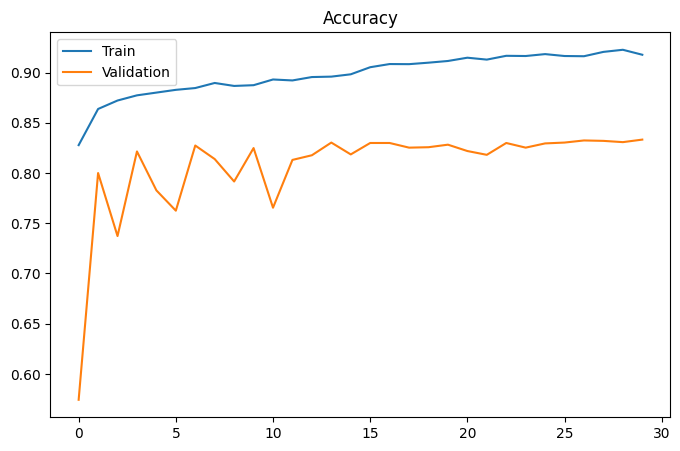

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.legend(["Train","Validation"])

plt.title("Accuracy")

plt.show()

**Loss**

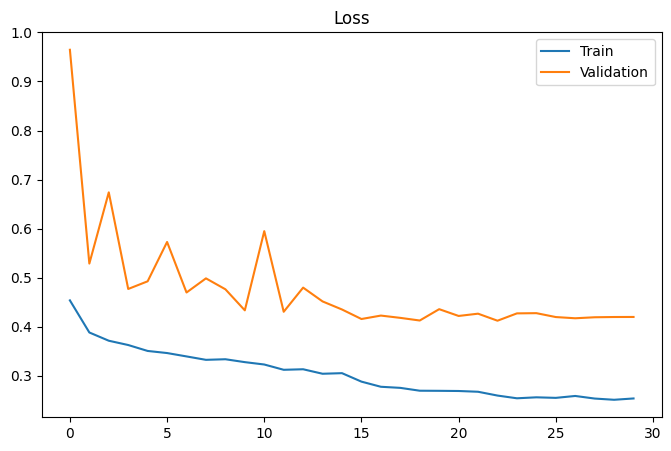

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.legend(["Train","Validation"])

plt.title("Loss")

plt.show()

**Precision**

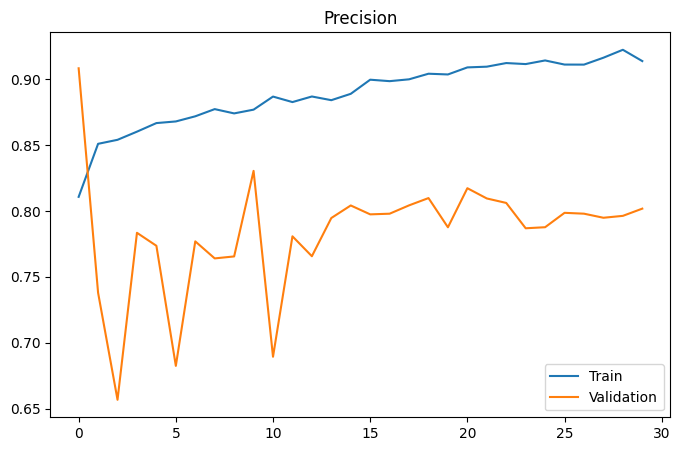

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["precision"])

plt.plot(history.history["val_precision"])

plt.legend(["Train","Validation"])

plt.title("Precision")

plt.show()

**Recall**

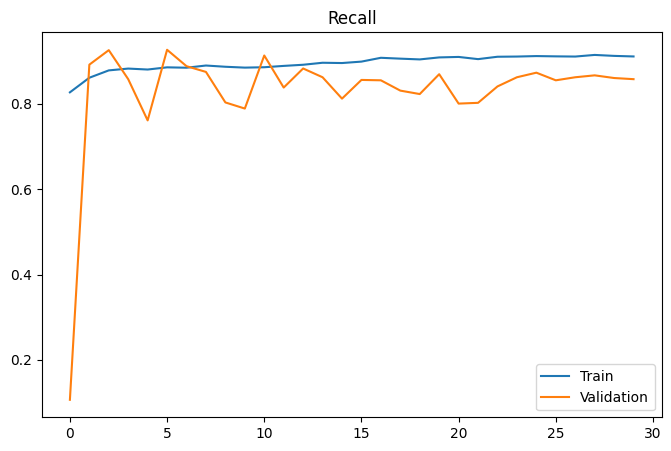

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["recall"])

plt.plot(history.history["val_recall"])

plt.legend(["Train","Validation"])

plt.title("Recall")

plt.show()

**AUC**

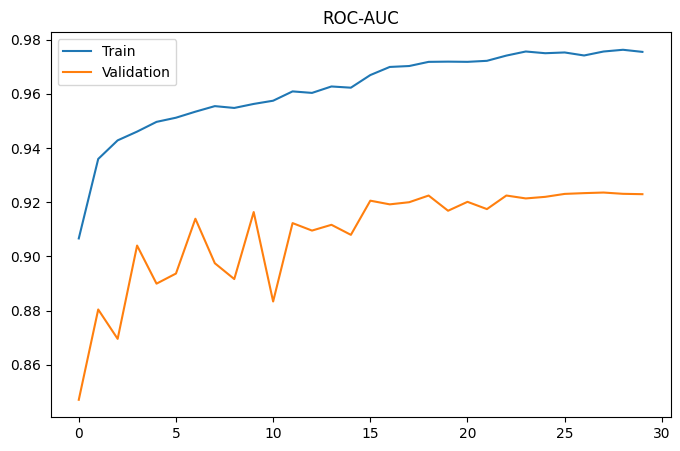

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["auc"])

plt.plot(history.history["val_auc"])

plt.legend(["Train","Validation"])

plt.title("ROC-AUC")

plt.show()

# **Step 25 — Evaluate on the Test Set**

In [ ]:
results = model.evaluate(test_generator)

for metric, value in zip(model.metrics_names, results):

    print(metric, ":", value)

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.9260 - auc: 0.9796 - loss: 0.2609 - precision: 0.9513 - recall: 0.8980
loss : 0.2609488368034363
compile_metrics : 0.9259999990463257


# **Step 26 — Predictions**

In [ ]:
pred = model.predict(test_generator)

pred = (pred > 0.5).astype(int).flatten()

true = test_generator.classes

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step


# **Step 27 — Classification Report**

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    true,
    pred,
    target_names=test_generator.class_indices.keys()
))

              precision    recall  f1-score   support

      Benign       0.90      0.95      0.93      1000
   Malignant       0.95      0.90      0.92      1000

    accuracy                           0.93      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.93      0.93      0.93      2000



# **Step 28 — Confusion Matrix**

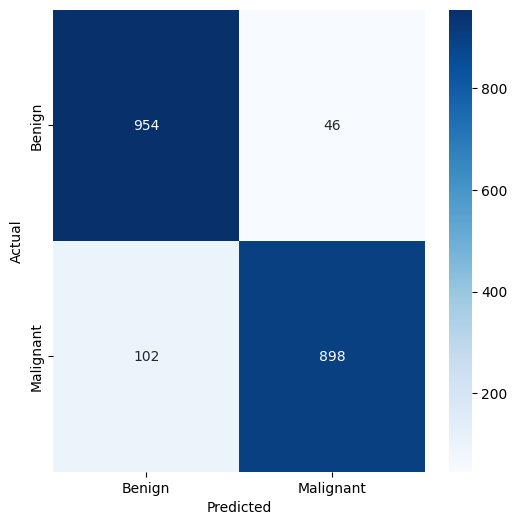

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true,pred)

plt.figure(figsize=(6,6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=test_generator.class_indices.keys(),

    yticklabels=test_generator.class_indices.keys()

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# **Step 29 — ROC Curve**

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step


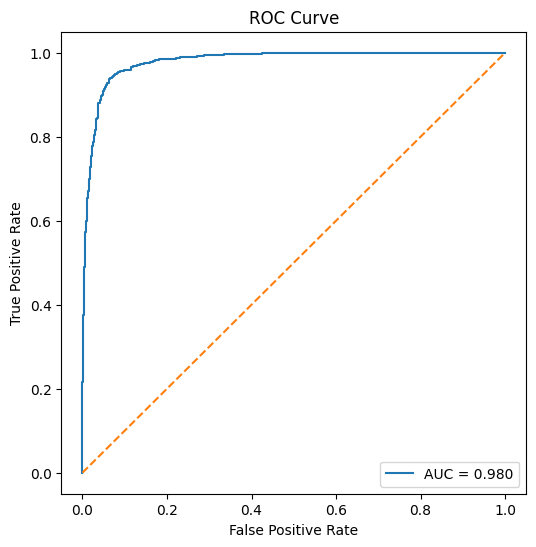

In [ ]:
from sklearn.metrics import roc_curve, auc

prob = model.predict(test_generator).ravel()

fpr,tpr,_ = roc_curve(true,prob)

roc_auc = auc(fpr,tpr)

plt.figure(figsize=(6,6))

plt.plot(fpr,tpr,label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.title("ROC Curve")

plt.show()

# **Step 30 — Precision–Recall Curve**

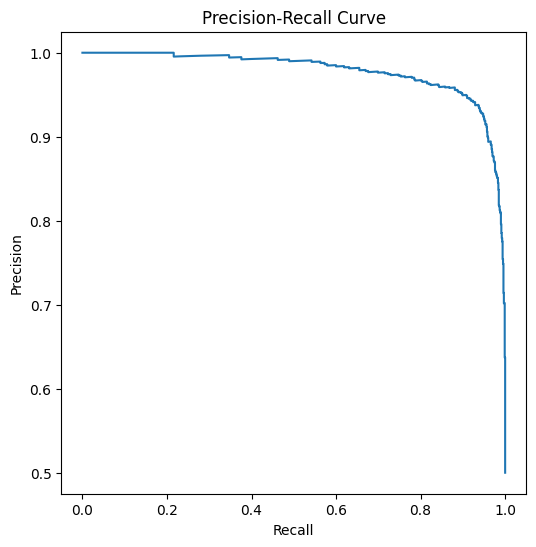

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(true, prob)

plt.figure(figsize=(6,6))

plt.plot(recall, precision)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.show()

# **Step 31 — Save Final Model**

In [ ]:
model.save("Improved_CNN.keras")

In [ ]:
model.save('/content/drive/MyDrive/Improved_CNN.keras')